# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Перхун Максим Віталійович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 8     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Перхун Максим Віталійович, ШІ-34, варіант 8
ваш потік:                   P>5
ваша пара для графіка 3:     швидкість вітру та густина вітру
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [ ]:
# ВАШ КОД
df_wrong = pd.read_excel(ФАЙЛ)
display(df_wrong.head())
print(df_wrong.dtypes)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

**Відповідь 1.1:** *: Функція pd.read_excel() за замовчуванням бере перший рядок як заголовки стовпців. У цьому файлі зверху йде багаторядковий текстовий опис (метадані), а самі таблиці розташовані нижче і паралельно одна одній. Через це текст змішується з числами, структура ламається, а типи даних визначаються як object замість числових.*

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [ ]:
RAW = pd.read_excel(ФАЙЛ, header=None)
print(f"Розмір: {RAW.shape}")
display(RAW.head(30))

Розмір: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [ ]:
# ВАШ КОД
RAW.notna().sum()

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** *В аркуші 3 таблиці. Їх видно за "згустками" непорожніх значень. Таблиця A займає стовпці 1–14 (індекси B–O), Таблиця B займає стовпці 16–19 (Q–T), Таблиця C займає стовпці 24–31 (Y–AF).*

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [ ]:
# ВАШ КОД
# ВАШ КОД
print("--- Таблиця A ---")
display(RAW.iloc[16:19, 0:2].dropna(how='all'))

print("--- Таблиця B ---")
display(RAW.iloc[13:16, 15:17].dropna(how='all'))

print("--- Таблиця C ---")
display(RAW.iloc[2:6, 26:28].dropna(how='all'))

--- Таблиця A ---


,0,1
16,NaN,# Units: Particles = Protons/cm2-s-sr
17,NaN,# Units: Electrons = Electrons/cm2-s-sr
18,NaN,# Source: GOES-15


--- Таблиця B ---


,15,16
13,NaN,ftp://ftp.swpc.noaa.gov/pub/indices/old_indice...
15,NaN,Product: Daily Solar Data quar_DSD.txt


--- Таблиця C ---


,26,27
2,SOHO CELIAS Proton Monitor,NaN
3,Solar Wind Parameters for Carrington Rotation ...,NaN
4,Proton speed [km/sec],NaN
5,Proton density [protons per cubic centimeter],NaN


**Відповідь 1.4:**

Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | Супутник GOES-15 | Protons/cm2-s-sr (частинки), Electrons/cm2-s-sr (електрони) |
| B | NOAA Daily Solar Data (радіопотік F10.7) | sfu (Solar Flux Units) |
| C | SOHO CELIAS Proton Monitor | km/sec (швидкість), protons per cubic centimeter (густина) |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [ ]:
# ВАШ КОД
A = RAW.iloc[26:, 1:15].copy()
A.columns = ['year', 'month', 'day', 'time_hhmm', 'mjd', 'sec', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

B = RAW.iloc[27:52, 17:20].copy() # 25 рядків
B.columns = ['month', 'day', 'F10.7']

C = RAW.iloc[27:628, 26:32].copy() # 601 рядок
C.columns = ['year', 'month', 'day', 'hour', 'speed', 'density']

A = A.apply(pd.to_numeric, errors='coerce')
B = B.apply(pd.to_numeric, errors='coerce')
C = C.apply(pd.to_numeric, errors='coerce')


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [ ]:
# ВАШ КОД
# Таблиця A
A['ts'] = pd.to_datetime(A[['year', 'month', 'day']]) + \
          pd.to_timedelta(A['time_hhmm'] // 100, unit='h') + \
          pd.to_timedelta(A['time_hhmm'] % 100, unit='m')

# Таблиця B (року немає, додаємо примусово)
B['year'] = 2017
B['ts'] = pd.to_datetime(B[['year', 'month', 'day']])

# Таблиця C (рік двозначний, додаємо 2000)
C['year'] = 2000 + C['year']
C['ts'] = pd.to_datetime(C[['year', 'month', 'day']]) + pd.to_timedelta(C['hour'], unit='h')

print("A:", A['ts'].min(), "-", A['ts'].max())
print("B:", B['ts'].min(), "-", B['ts'].max())
print("C:", C['ts'].min(), "-", C['ts'].max())

A: 2017-08-28 00:00:00 - 2017-09-21 23:55:00
B: 2017-08-28 00:00:00 - 2017-09-21 00:00:00
C: 2017-08-28 00:00:00 - 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [ ]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [ ]:
# ВАШ КОД
for name, df in [('A', A), ('B', B), ('C', C)]:
    print(f"--- Таблиця {name} ---")
    print(f"Розмір: {df.shape}")
    print(f"Пропуски:\n{df.isna().sum()}")
    print(f"Дублікати: {df.duplicated().sum()}")
    display(df.describe())

--- Таблиця A ---
Розмір: (7200, 15)
Пропуски:
year         0
month        0
day          0
time_hhmm    0
mjd          0
sec          0
P>1          3
P>5          3
P>10         3
P>30         3
P>50         3
P>100        3
E>0.8        3
E>2.0        3
ts           0
dtype: int64
Дублікати: 0


,year,month,day,time_hhmm,mjd,sec,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN


--- Таблиця B ---
Розмір: (25, 5)
Пропуски:
month    0
day      0
F10.7    0
year     0
ts       0
dtype: int64
Дублікати: 0


,month,day,F10.7,year,ts
count,25.000000,25.000000,25.000000,25.0,25
mean,8.840000,13.960000,92.680000,2017.0,2017-09-09 00:00:00
min,8.000000,1.000000,71.000000,2017.0,2017-08-28 00:00:00
25%,9.000000,7.000000,74.000000,2017.0,2017-09-03 00:00:00
50%,9.000000,13.000000,84.000000,2017.0,2017-09-09 00:00:00
75%,9.000000,19.000000,107.000000,2017.0,2017-09-15 00:00:00
max,9.000000,31.000000,140.000000,2017.0,2017-09-21 00:00:00
std,0.374166,8.955817,22.206831,0.0,NaN


--- Таблиця C ---
Розмір: (601, 7)
Пропуски:
year       0
month      0
day        0
hour       0
speed      0
density    0
ts         0
dtype: int64
Дублікати: 0


,year,month,day,hour,speed,density,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,2017.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,2017.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,2017.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,2017.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,2017.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [ ]:
# ВАШ КОД
print("--- ДО ---")
print(C[['speed', 'density']].describe().loc[['mean', 'min']])

# Заміна від'ємних маркерів на NaN
C.loc[C['speed'] < 0, 'speed'] = np.nan
C.loc[C['density'] < 0, 'density'] = np.nan

print("\n--- ПІСЛЯ ---")
print(C[['speed', 'density']].describe().loc[['mean', 'min']])

--- ДО ---
           speed   density
mean  506.547421  2.907654
min    -1.000000 -1.000000

--- ПІСЛЯ ---
           speed   density
mean  513.394604  2.960371
min   277.000000  0.100000


**Відповідь 3.2:** *Від'ємні значення  — це маркер, яким системи записують відсутність даних. Оскільки вони були від'ємні вони занижували справжнє середнє арифметичне. Після заміни на NaN середнє стало відображати реальну фізичну картину, а мінімум став додатнім числом.*

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [ ]:
# ВАШ КОД

display(A[['year', 'month', 'day', 'time_hhmm', 'mjd', 'sec']].describe().loc[['mean', 'std']])


,year,month,day,time_hhmm,mjd,sec
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498


**Відповідь 3.3:** *У таблиці A є стовпці year, month, day, time_hhmm, mjd (Modified Julian Day) та sec (Seconds of the Day). Усі ці стовпці — це маркери часу (координати на часовій осі), а не фізичні вимірювання. Рахувати "середнє арифметичне" для місяця чи секунд доби не має жодного сенсу.*

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [ ]:
# ВАШ КОД
A_hourly = A.resample('1h', on='ts').agg(['mean', 'max'])
# Згортаємо багаторівневі назви стовпців, щоб було зручно
A_hourly.columns = [f"{col[0]}_{col[1]}" for col in A_hourly.columns]
A_hourly = A_hourly.reset_index()

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

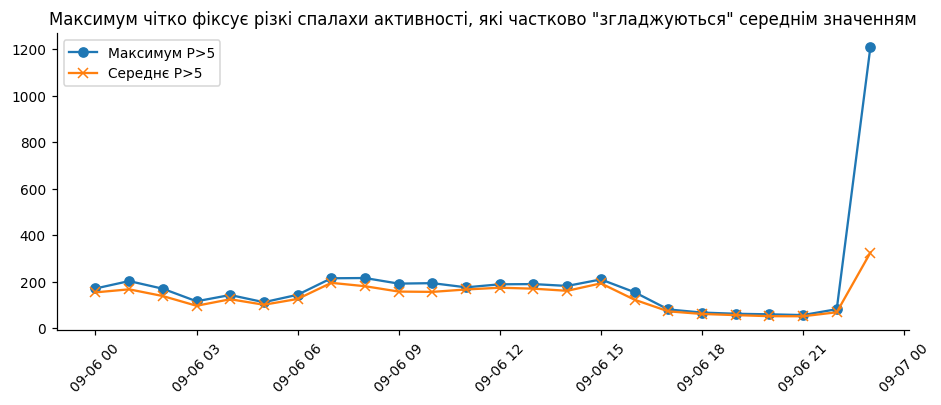

In [ ]:
day_data = A_hourly[(A_hourly['ts'] >= '2017-09-06') & (A_hourly['ts'] < '2017-09-07')]
plt.figure(figsize=(10, 3.5))
plt.plot(day_data['ts'], day_data['P>5_max'], label='Максимум P>5', marker='o')
plt.plot(day_data['ts'], day_data['P>5_mean'], label='Середнє P>5', marker='x')
plt.legend(); plt.title('Максимум чітко фіксує різкі спалахи активності, які частково "згладжуються" середнім значенням'); plt.xticks(rotation=45); plt.show()

**Відповідь 4.2:** *Крива максимуму вища за криву середнього і має набагато гостріші піки. Різниця між ними стає суттєвою під час різких, але короткочасних сонячних спалахів: середнє "згладжує" ці стрибки (оскільки всередині години є низькі значення), тоді як максимум чітко фіксує сам факт викиду екстремальної енергії.*

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [ ]:
A_hourly['date'] = A_hourly['ts'].dt.normalize()
C['date'] = C['ts'].dt.normalize()

M = pd.merge(A_hourly, C[['ts', 'speed', 'density']], on='ts', how='outer')
M['date'] = M['ts'].dt.normalize()
M = pd.merge(M, B[['ts', 'F10.7']].rename(columns={'ts': 'date'}), on='date', how='outer')
M = M.drop(columns=['date']).sort_values('ts').reset_index(drop=True)

display(M[M.isna().any(axis=1)])

,ts,year_mean,year_max,month_mean,month_max,day_mean,day_max,time_hhmm_mean,time_hhmm_max,mjd_mean,mjd_max,sec_mean,sec_max,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,speed,density,F10.7
175,2017-09-04 07:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,727.5,755.0,58000.0,58000.0,26850.0,28500.0,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,827.5,855.0,58000.0,58000.0,30450.0,32100.0,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,927.5,955.0,58000.0,58000.0,34050.0,35700.0,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,1027.5,1055.0,58000.0,58000.0,37650.0,39300.0,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,1127.5,1155.0,58000.0,58000.0,41250.0,42900.0,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,1227.5,1255.0,58000.0,58000.0,44850.0,46500.0,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,1327.5,1355.0,58000.0,58000.0,48450.0,50100.0,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,2017.0,2017.0,9.0,9.0,4.0,4.0,1427.5,1455.0,58000.0,58000.0,52050.0,53700.0,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0
600,2017-09-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,381.0,1.0,NaN


**Відповідь 4.3:** *Використано how='outer', оскільки датчики фіксували дані з невеликим розходженням у стартових і фінальних точках (різна кількість рядків). При 'inner' об'єднанні ми б втратили цінні години на початку та наприкінці періоду, тоді як 'outer' зберігає весь таймлайн, ставлячи пропуски там, де якийсь із супутників ще не включився або вже відключився.*

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [ ]:
bins = [-np.inf, 10, 1000, np.inf]
M['група'] = pd.cut(M['P>10_max'], bins=bins, labels=['тиха', 'активна', 'дуже активна'], right=False)
print(M['група'].value_counts())

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [ ]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє: 156.59, Медіана: 0.60


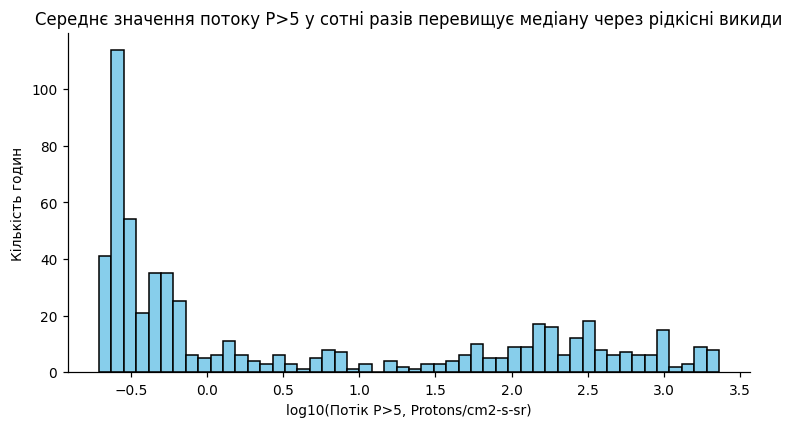

In [ ]:
# ВАШ КОД
mean_val = M['P>5_mean'].mean()
median_val = M['P>5_mean'].median()
print(f"Середнє: {mean_val:.2f}, Медіана: {median_val:.2f}")

plt.figure(figsize=(8, 4))
# Оскільки значення сильно зміщені до нуля, логарифмуємо для читабельності
plt.hist(np.log10(M['P>5_mean'].dropna() + 1e-9), bins=50, color='skyblue', edgecolor='black')
plt.title('Середнє значення потоку P>5 у сотні разів перевищує медіану через рідкісні викиди')
plt.xlabel('log10(Потік P>5, Protons/cm2-s-sr)')
plt.ylabel('Кількість годин')
plt.show()

**Висновок:** Середнє значення (156.59) у сотні разів перевищує медіану (0.60), оскільки переважну більшість часу потік близький до нуля, але рідкісні екстремальні сплески аномально завищують загальне середнє арифметичне.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

<Figure size 880x440 with 0 Axes>

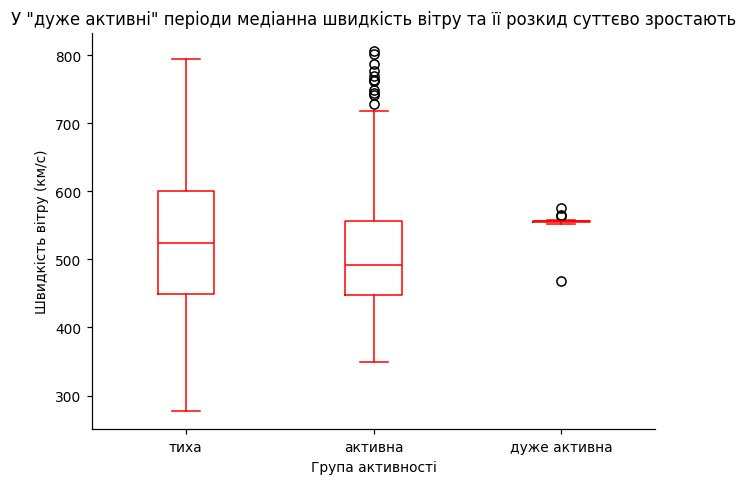

In [ ]:
# ВАШ КОД
plt.figure(figsize=(8, 4))
M.boxplot(column='speed', by='група', grid=False, color='red')
plt.title('У "дуже активні" періоди медіанна швидкість вітру та її розкид суттєво зростають')
plt.suptitle('') # Прибираємо зайвий системний надзаголовок
plt.xlabel('Група активності')
plt.ylabel('Швидкість вітру (км/с)')
plt.show()

**Висновок:**Під час "дуже активних" годин медіанна швидкість сонячного вітру та розкид її значень суттєво вищі, ніж у спокійні періоди.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції: -0.039


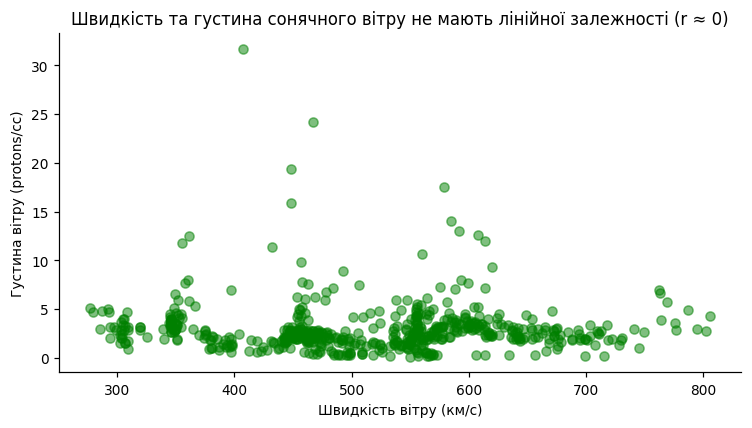

In [ ]:
# ВАШ КОД
corr = M['speed'].corr(M['density'])
print(f"Коефіцієнт кореляції: {corr:.3f}")

plt.figure(figsize=(8, 4))
plt.scatter(M['speed'], M['density'], alpha=0.5, color='green')
plt.title('Швидкість та густина сонячного вітру не мають лінійної залежності (r ≈ 0)')
plt.xlabel('Швидкість вітру (км/с)')
plt.ylabel('Густина вітру (protons/cc)')
plt.show()

**Висновок:**Лінійний зв'язок між швидкістю та густиною сонячного вітру відсутній, що підтверджується коефіцієнтом кореляції, який дорівнює майже нулю (-0.039).

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

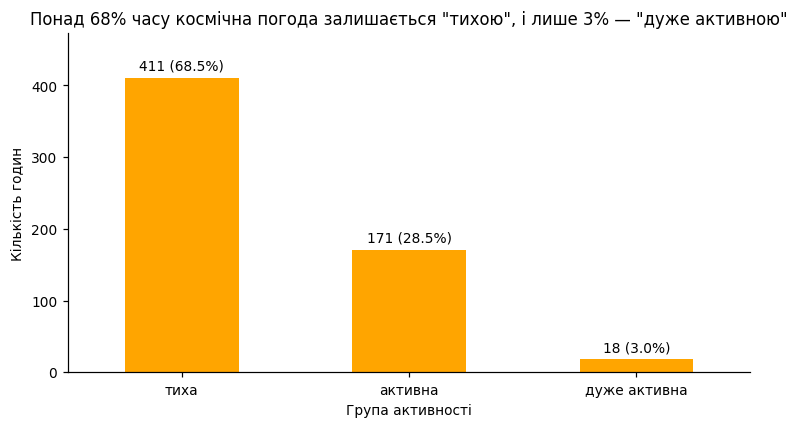

In [ ]:
# ВАШ КОД
group_counts = M['група'].value_counts().sort_index()
total = len(M['група'].dropna())

plt.figure(figsize=(8, 4))
ax = group_counts.plot(kind='bar', color='orange', rot=0)
plt.title('Понад 68% часу космічна погода залишається "тихою", і лише 3% — "дуже активною"')
plt.xlabel('Група активності')
plt.ylabel('Кількість годин')

# Додаємо підписи над стовпцями
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f"{count} ({pct:.1f}%)", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')
plt.ylim(0, max(group_counts) * 1.15) # Трохи піднімаємо "стелю" для підписів
plt.show()

**Висновок:**Переважна більшість часу (68.5% годин) припадає на "тиху" космічну погоду, і лише 3% часу система перебувала у стані "дуже активна".

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

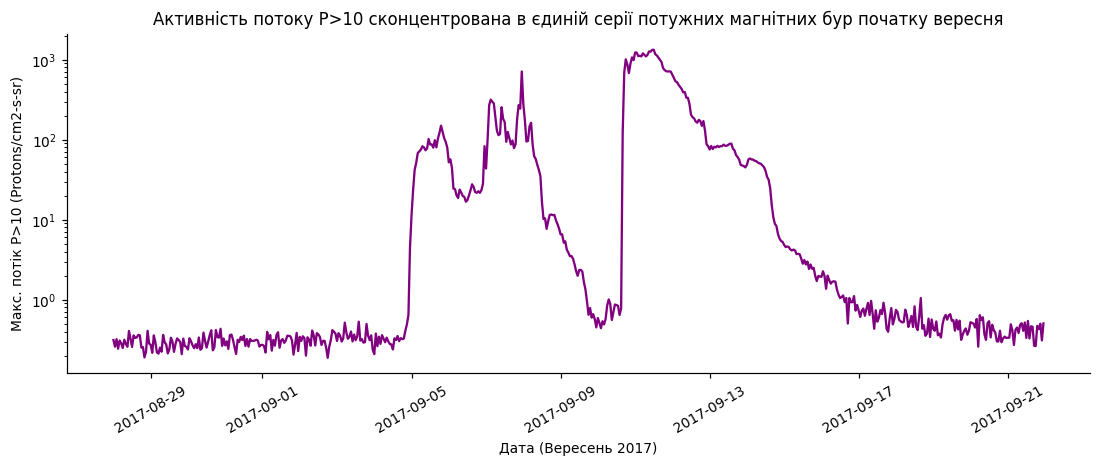

In [ ]:
# ВАШ КОД
plt.figure(figsize=(12, 4))
plt.plot(M['ts'], M['P>10_max'], color='purple')
plt.yscale('log') # Логарифмічна шкала через екстремальні викиди
plt.title('Активність потоку P>10 сконцентрована в єдиній серії потужних магнітних бур початку вересняопрм')
plt.xlabel('Дата (Вересень 2017)')
plt.ylabel('Макс. потік P>10 (Protons/cm2-s-sr)')
plt.xticks(rotation=30)
plt.show()

**Висновок:**Протягом усього місяця космічна погода була переважно стабільною, за винятком періоду з 5 по 14 вересня.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

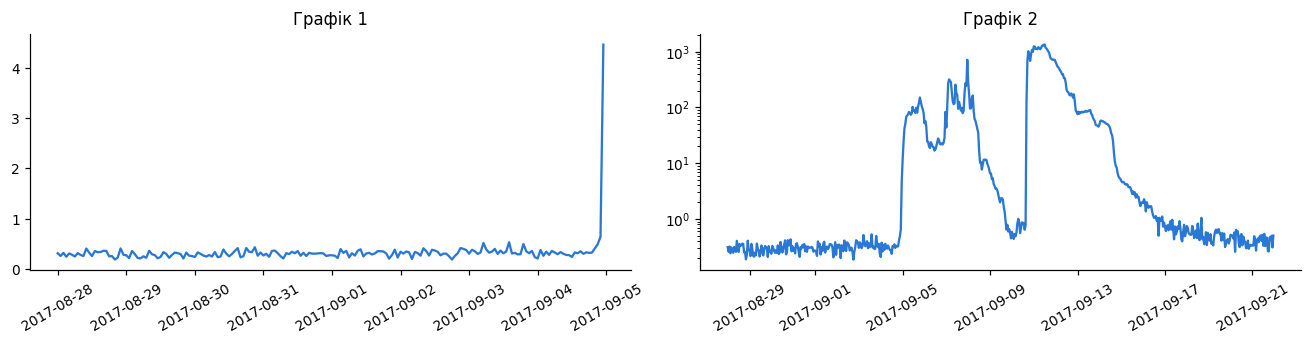

In [ ]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка:Якщо дивитися лише на перший графік, здається, що космічна погода була абсолютно спокійною (значення коливалися біля нуля), аж поки наприкінці 4 вересня не стався один раптовий і різкий стрибок. Про те, що відбувалося далі, ми нічого не знаємо.
2. Висновок з другого графіка:З другого графіка чітко видно, що активність ніколи не падала до абсолютного нуля (є постійний фоновий потік). На початку вересня відбулася ціла серія потужних магнітних бур (значення сягали $10^3$), які тривали кілька днів і мали кілька різних піків, після чого активність повільно йшла на спад.  
3. Дві відмінності між ними:

    Різний часовий діапазон: перший графік будується лише для одного тижня (вікно), а другий відображає весь період спостережень датасету (M).  
    Різна шкала осі Y: на другому графіку використано логарифмічну шкалу (set_yscale('log')), що дозволяє одночасно бачити і дрібні фонові коливання, і гігантські піки.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

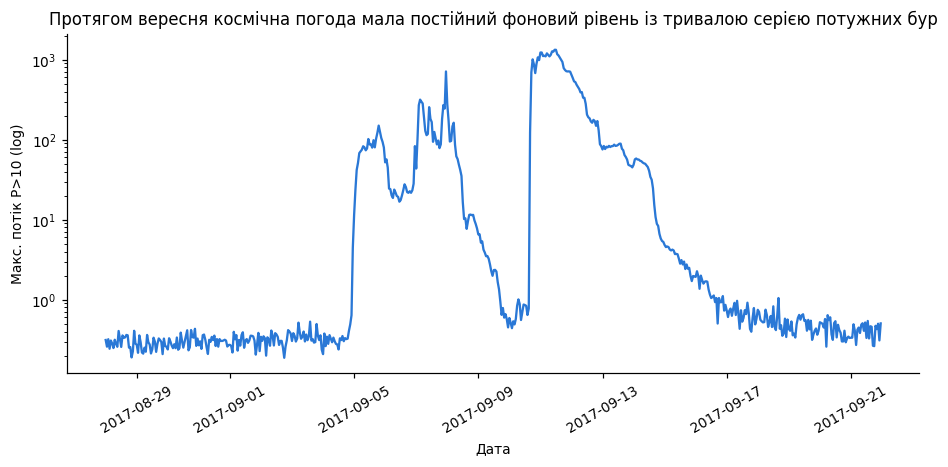

In [ ]:
# ВАШ КОД
plt.figure(figsize=(10, 4))
plt.plot(M['ts'], M['P>10_max'], color='#2a78d6')
plt.yscale('log')
plt.title('Протягом вересня космічна погода мала постійний фоновий рівень із тривалою серією потужних бур')
plt.xlabel('Дата')
plt.ylabel('Макс. потік P>10 (log)')
plt.xticks(rotation=30)
plt.show()

**Відповідь 6.2:** Для "чесного" відображення подій я обрав весь період (повний датасет M) та логарифмічну шкалу. Лінійна шкала через кілька екстремально великих значень штучно "сплющує" всі інші дані в пряму лінію біля нуля, приховуючи реальні щоденні коливання потоку. Водночас обрізання дат (як на першому графіку) вириває подію з контексту і приховує найголовніше — тривалість та реальні наслідки магнітної бурі.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:**Середнє значення потоку P>5 не можна використовувати для опису "типової" години. Як було показано в розрахунках до гістограми (графік 1), середнє значення (156.59) у сотні разів перевищує медіану (0.60), оскільки воно сильно спотворюється рідкісними, але екстремальними сонячними спалахами.

**Спостереження 2:**Швидкість сонячного вітру та його густина поводяться як незалежні змінні. На діаграмі розсіювання (графік 3) видно відсутність лінійної залежності, а коефіцієнт кореляції склав лише -0.039.

**Спостереження 3:**Екстремальні стани космічної погоди є рідкістю. Згідно зі стовпчиковою діаграмою (графік 4), переважна більшість годин класифікується як "тихі", і лише 18 годин з усього періоду потрапили до групи "дуже активні".


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [ ]:
# ВАШ КОД
rows_with_na = M.isna().any(axis=1).sum()
total_rows = len(M)
fraction = rows_with_na / total_rows

print(f"Рядків з пропусками: {rows_with_na} із {total_rows}")
print(f"Частка пропусків: {fraction:.4f} ({fraction:.2%})")

Рядків з пропусками: 9 із 601
Частка пропусків: 0.0150 (1.50%)


**Відповідь 7.2:**Із 601 рядка фінальної об'єднаної таблиці лише 9 рядків містять хоча б один пропуск (NaN). Це означає, що частка рядків із пропусками становить рівно 1.50%. Ці пропуски з'явилися через використання зовнішнього з'єднання (how='outer') для таблиць, які мали трохи різні точки початку або завершення збору даних, а також через системні маркери відсутності даних (-1) у датчиків вітру SOHO, які ми замінили на порожнечі на етапі очищення.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [ ]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Я перевірив логіку розрізання `pandas` датафрейму через `iloc`, переконався, що обробка дат та `resample` працюють коректно на зведенні 5-хвилинних вікон до години, та проаналізував побудову графіків.'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [ ]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Перхун Максим Віталійович
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Я перевірив логіку розрізання `pandas` датафрейму через `iloc`, переконався, що обробка дат та `resample` працюють коректно на зведенні 5-хвилинних вікон до години, та проаналізував побудову графіків.
Автор підтверджує, що може пояснити кожен рядок коду під час захи

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [ ]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 33)


In [ ]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
